# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Four trials are registered. **Best = trial_01** (objective 0.1127). Ranking and configs (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_01 (0.1127, best, 0 diverged):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (mu travel 0.120). mu rel-RMSE 77.1% (mid-T overshoot 1nW T20 +157%, 3nW T05 +137%; high-T undershoot 3nW T60 -23%, T100 -38%), gamma rel-RMSE 21.5%.
- **trial_03 (0.1362, 1 diverged):** `lr_mu=0.1076`, `mu_anneal=0.6301`, `lr_gamma=0.9349`, `gamma_anneal=0.5944` (travel 0.074). Best mu accuracy (rel-RMSE 55.1%), but high-T mu undershoot widened and 1nW T05 gamma diverged (2.7e10).
- **trial_04 (0.1418, 1 diverged):** `lr_mu=0.1376`, `mu_anneal=0.9298`, `lr_gamma=0.6029`, `gamma_anneal=0.8452` (travel 0.074). Damped gamma step; 1nW T05 gamma still diverged (-5.3e16); mu rel-RMSE 60.0%.
- **trial_02 (0.1449, 1 diverged):** `lr_mu=0.2833`, `mu_anneal=0.1501`, `lr_gamma=0.6746`, `gamma_anneal=0.2475` (travel 0.264). Largest travel; worst mu (rel-RMSE 136%), 1nW T05 gamma diverged (mildly, -2.20).

Two facts stand out. (1) mu accuracy is best at the smallest travel (trial_03/04, 55-60%) and worst at the largest (trial_02, 136%), but the *objective* is still lowest for trial_01 because it balances the mid-T overshoot against the high-T undershoot. (2) The 1nW T05 gamma cell has diverged in trials 02, 03 and 04 and survived only in trial_01; damping the gamma step (trial_04) did not prevent it, so the trigger is not obviously the gamma LR. Cell 2 still reports `phase = uniform` (4/5 trials) — this is the last uninformed draw before expected-improvement proposals begin. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.7245026313708421, "lr_gamma": 0.8175437502496691, "lr_mu": 0.2600861527158603, "mu_anneal": 0.2858013800881416}
 2 |      - | {"gamma_anneal": 0.048537632143490786, "lr_gamma": 0.4142004367462423, "lr_mu": 0.20719423668289932, "mu_anneal": 0.045275193902445166}
 3 |      - | {"gamma_anneal": 0.04388193965445125, "lr_gamma": 0.9992173093118178, "lr_mu": 0.3279227102360539, "mu_anneal": 0.23451020166982395}
 4 |      - | {"gamma_anneal": 0.39145279700262786, "lr_gamma": 0.9754768835962926, "lr_mu": 0.44935041601373166, "mu_anneal": 0.844231037608741}
 5 |      - | {"gamma_anneal": 0.3531641979013004, "lr_gamma": 0.5183718677951554, "lr_mu": 0.3399612291563777, "mu_anneal": 0.06080271295805606}
 6 |      - | {"gamma_anneal": 0.5000365052286511, "lr_gamma": 0.3078790243035964, "lr_mu": 0.44042733080078644, "mu_anneal": 0.06421443731219101}
 7 |      - | {"gamma_anneal": 0.6112633797192285, "lr_gamma": 0.876

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Four trials done; the best is still trial_01 (0.1127), and every other trial is both worse and divergent at 1nW T05. There are still no expected-improvement values (cell 2 `phase = uniform`, 4/5), so this last uniform draw is best used to *refine around the current best* rather than to explore far away.

In normalized (unit-cube) coordinates the best trial_01 is at `lr_mu=0.303`, `mu_anneal=0.454`, `lr_gamma=0.788`, `gamma_anneal=0.330`. Distances of the candidates to that point:
- candidate 9: `lr_mu=0.106`, `mu_anneal=0.325`, `lr_gamma=0.465`, `gamma_anneal=0.453` -> closest overall (squared distance ~0.18); mu travel `0.106*0.838=0.088` (a little below trial_01's 0.120).
- candidate 1: `lr_mu=0.260`, `mu_anneal=0.286`, `lr_gamma=0.818`, `gamma_anneal=0.805` (~0.30); mu travel 0.223 (above trial_01).
- candidate 7: `lr_mu=0.118`, `mu_anneal=0.895`, `lr_gamma=0.877`, `gamma_anneal=0.611` (~0.33); mu travel 0.065 (well below trial_01).
- candidates 2/4/5/6/8/10: farther, all with lr_mu <=0.45 and mu travel >=0.20 or lr_gamma extreme (candidate 8 has `lr_gamma=0.068`, far too low to be a refinement).

Candidate 9 sits nearest the best configuration and, taken on its own axis, moves mu travel a little *below* trial_01's (0.088 vs 0.120) while keeping the gamma schedule in a moderate range — exactly the direction suggested by the only trend in the data (smaller travel improved mu accuracy in trials 03/04). It is a conservative refinement of the best point, unlike candidates 1/5/6 (back toward the bad large-travel region) or candidate 8 (`lr_gamma` far too small).

I choose candidate 9 (9 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 9            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.45302756899829805, 'lr_gamma': 0.46483369956687004, 'lr_mu': 0.10561015387670958, 'mu_anneal': 0.32494264457560607}
Running  1nW Trans05 ... 

μ 9.39 -> 10.02 | γ 8.5 -> 4.44 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 37.48 | γ 8.5 -> 5.92 | NLL 4.90


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 71.03 | γ 14.1 -> 14.33 | NLL 3.13


Running 3nW Trans100 ... 

μ 175.71 -> 104.07 | γ 14.1 -> 14.09 | NLL 3.32



Total: 7.8 min


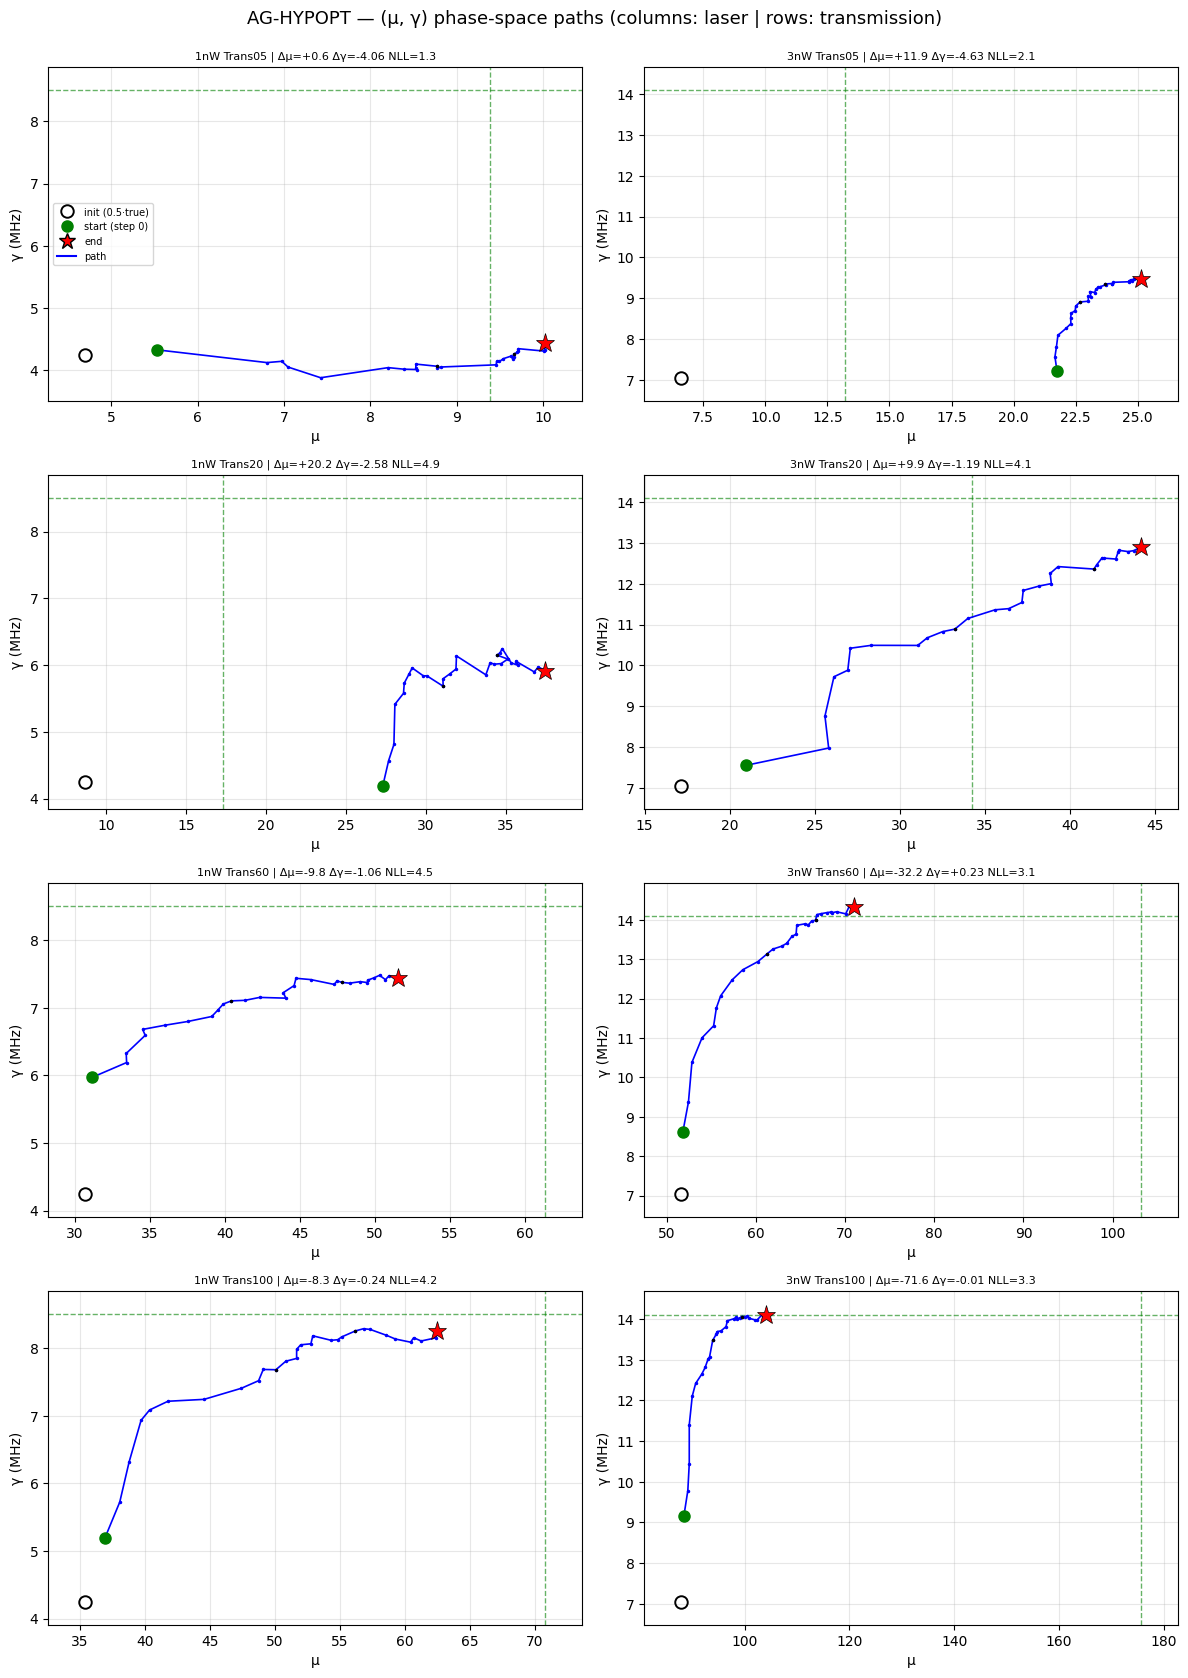

trial finished in 7.8 min
objective = 0.1135 ± 0.0748
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.02    +6.7 |     8.50    4.44   -47.7
1nW Trans20       17.32   37.48  +116.5 |     8.50    5.92   -30.4
1nW Trans60       61.37   51.55   -16.0 |     8.50    7.44   -12.5
1nW Trans100       70.82   62.49   -11.8 |     8.50    8.26    -2.9
3nW Trans05       13.20   25.14   +90.4 |    14.10    9.47   -32.8
3nW Trans20       34.28   44.21   +29.0 |    14.10   12.91    -8.5
3nW Trans60      103.20   71.03   -31.2 |    14.10   14.33    +1.6
3nW Trans100      175.71  104.07   -40.8 |    14.10   14.09    -0.1

weighted objective (T-graded, cap=1.0) = 0.1135 | diverged cells: 0
μ: RMSE 29.541 (rel 56.6%, bias -9.912) | γ: RMSE 2.430 (rel 23.8%, bias -1.694)


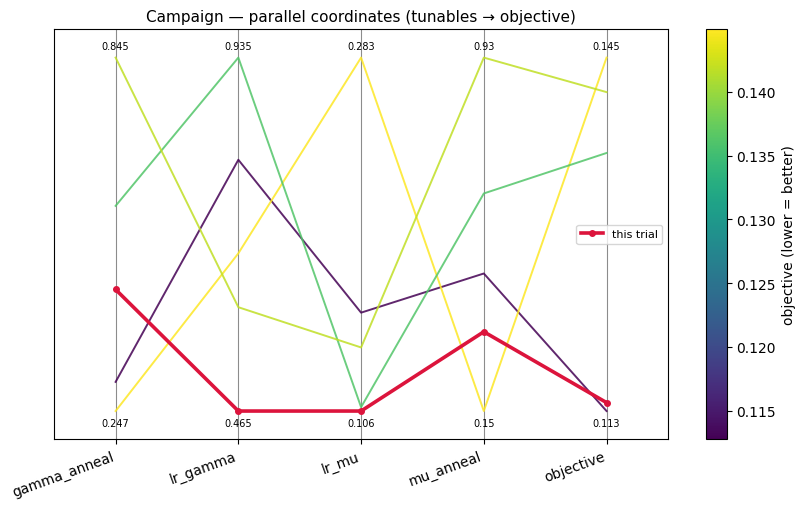

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 05 ran candidate 9: `lr_mu=0.1056`, `mu_anneal=0.3249` (effective mu travel 0.088, just below trial_01's 0.120), `lr_gamma=0.4648`, `gamma_anneal=0.4530`. It completed in 7.8 min with objective **0.1135 +/- 0.0748** and **0 diverged cells**. Ranking: trial_01 0.1127, **trial_05 0.1135**, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 56.6%** (RMSE 29.54, bias -9.91) — essentially trial_03/04's good mu (55-60%) and much better than trial_01's 77.1%; **gamma rel-RMSE 23.8%** (RMSE 2.43, bias -1.69), comparable to trial_01's 21.5% and the best gamma of any trial that did not diverge.

Per-cell relative errors:
- **mu:** 1nW T05 +6.7%, T20 +116.5%, T60 -16.0%, T100 -11.8% | 3nW T05 +90.4%, T20 +29.0%, T60 -31.2%, T100 -40.8%.
- **gamma:** 1nW T05 -47.7%, T20 -30.4%, T60 -12.5%, T100 -2.9% | 3nW T05 -32.8%, T20 -8.5%, T60 +1.6%, T100 -0.1%.

This is the closest any trial has come to beating trial_01, and it does so on the terms that matter: the objective is a tie within uncertainty (0.1135 vs 0.1127), but the **1nW T05 gamma cell stayed finite (-47.7%)** for the first time since trial_01, and mu accuracy is much better (rel-RMSE 77.1% -> 56.6%). The improvement comes from the mu side: the mid-T overshoot is contained (1nW T20 +116.5%, 3nW T05 +90.4%, both far below the +137-157% of trial_01) at the cost of a somewhat larger high-T undershoot (3nW T60 -31.2%, T100 -40.8%). The gamma step is lower than trial_01's (`lr_gamma` 0.465 vs 0.799) and gamma still lands well at high T.

**Summary:** Trial 05 (lr_mu=0.1056, mu_anneal=0.3249, lr_gamma=0.4648, gamma_anneal=0.4530): objective 0.1135 +/- 0.0748 with 0 diverged cells; effectively tied with trial_01 (0.1127) but with much better mu accuracy (rel-RMSE 77% -> 57%) and gamma finite on all 8 cells - the first run since trial_01 to avoid the 1nW T05 gamma blow-up.
**Key insight:** Moderately reducing mu travel (0.120 -> 0.088) together with a lower gamma step reaches trial_01's objective (0.1135) while eliminating the 1nW T05 gamma divergence and cutting mu rel-RMSE from 77% to 57%, making this the best-behaved configuration so far.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The 1nW T05 gamma behaviour is sensitive to small changes: travel 0.074 (trials 03/04) diverged, but travel 0.088 with `lr_gamma=0.465` (trial 05) stayed finite. That is a narrow boundary, so the divergence-free result may not be robust to re-runs; it is worth watching whether the next trials around this point reproduce it. The per-experiment/n_target-adaptive gamma step idea (recorded earlier) remains the structural candidate if the cell re-diverges; noted only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 05 (lr_mu=0.1056, mu_anneal=0.3249, lr_gamma=0.4648, gamma_anneal=0.4530): objective 0.1135 +/- 0.0748 with 0 diverged cells; effectively tied with trial_01 (0.1127) but with much better mu accuracy (rel-RMSE 77% -> 57%) and gamma finite on all 8 cells - the first run since trial_01 to avoid the 1nW T05 gamma blow-up"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Moderately reducing mu travel (0.120 -> 0.088) together with a lower gamma step reaches trial_01's objective (0.1135) while eliminating the 1nW T05 gamma divergence and cutting mu rel-RMSE from 77% to 57%, making this the best-behaved configuration so far"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
